# Chicago Risk District Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt
from statsmodels.tsa.seasonal import STL
import geopandas as gpd
from shapely.geometry import shape, Point
import contextily as ctx
from json import loads

In [2]:
from sys import path

path.insert(0, '../modules')

import utils as f
import params_cfg as pc
import visuals

colors = pc.COLORS
gen_theft = pc.GENERAL_THFT
gen_aslt = pc.GENERAL_ASLT
census_data = pc.CENSUS_DATA

%load_ext autoreload
%autoreload 2

In [3]:
# defining the project paths
brz_path = pc.BRZ_PATH
slv_path = pc.SLV_PATH
gld_path = pc.GLD_PATH
img_path = pc.IMG_PATH
model_path = pc.MODEL_PATH

In [9]:
df_crime = pd.read_csv(
    f'{slv_path}/df_crime_final.csv',
    index_col='date',
    parse_dates=True
)

df_crime['id'] = df_crime['id'].astype(str)
df_crime['district'] = df_crime['district'].astype(str)
df_crime['ddate'] = pd.to_datetime(df_crime.index.date)

df_crime.head()

,id,arrest,domestic,district,community_area,crime_lat,crime_lon,crime_group,crime_distance,min_dist_station,...,avg_per_capita_income,avg_hardship_index,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index,ddate
date,,,,,,,,,,,,,,,,,,,,,
2022-06-15 22:15:00,12731205,0,0,12,28,41.880463,-87.648933,THFT,2.055243,2.055243,...,38318.7,40.500000,0.038,0.206,0.107,0.096,0.222,44689.0,15,2022-06-15
2022-06-15 22:15:00,12732249,0,0,12,27,41.881936,-87.701870,ASLT,4.273667,0.975971,...,38318.7,40.500000,0.082,0.424,0.196,0.213,0.432,12961.0,83,2022-06-15
2022-06-15 22:15:00,12762227,0,0,7,67,41.793611,-87.668707,ASLT,1.684247,1.684247,...,14986.0,76.142857,0.048,0.344,0.359,0.263,0.407,11317.0,89,2022-06-15
2022-06-15 22:15:00,12731213,1,0,7,67,41.773605,-87.659202,ASLT,0.684559,0.684559,...,14986.0,76.142857,0.048,0.344,0.359,0.263,0.407,11317.0,89,2022-06-15
2022-06-15 22:25:00,12731126,0,0,12,28,41.877618,-87.680568,THFT,2.543153,2.111527,...,38318.7,40.500000,0.038,0.206,0.107,0.096,0.222,44689.0,15,2022-06-15


## Time Analysis

### Daily Count

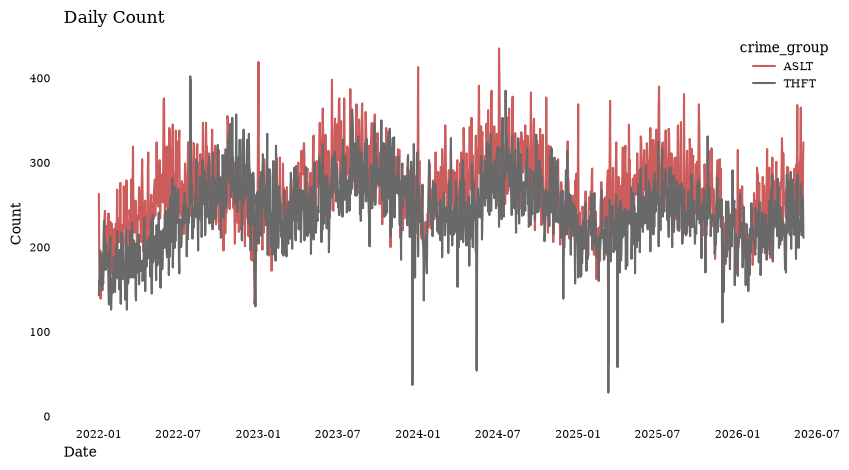

In [49]:
grp = df_crime[['ddate', 'crime_group', 'id']]\
    .groupby(['ddate', 'crime_group'])\
    .count()\
    .reset_index()

sns.lineplot(
    data=grp,
    x='ddate',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.ylim(0)
plt.title('Daily Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Date', loc='left')
plt.box(False);

### Moving Average

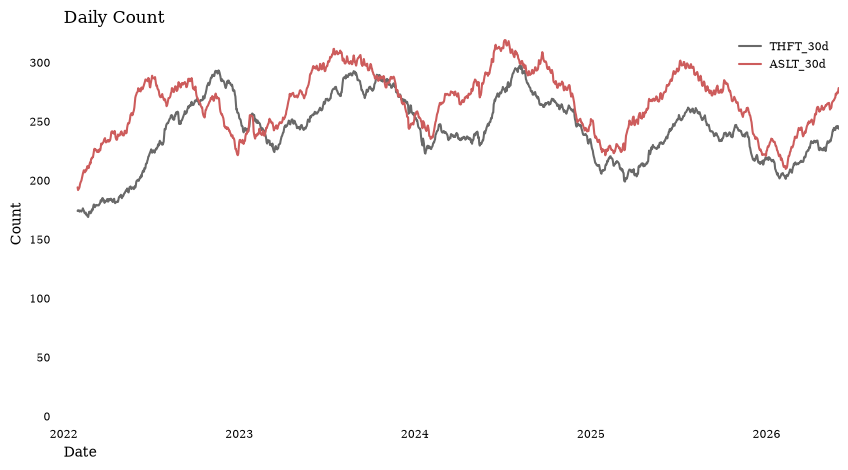

In [65]:
grp = df_crime[['ddate', 'crime_group', 'id']]\
    .groupby(['ddate', 'crime_group'])\
    .count()\
    .reset_index()


grp_aslt = grp.query('crime_group == "ASLT"').copy()
grp_thft = grp.query('crime_group == "THFT"').copy()

k = 30
grp_aslt[f'ASLT_{k}d'] = grp_aslt['id'].rolling(k).mean()
grp_thft[f'THFT_{k}d'] = grp_thft['id'].rolling(k).mean()

grp_ma = grp_thft[['ddate', f'THFT_{k}d']].merge(
    grp_aslt[['ddate', f'ASLT_{k}d']],
    how='inner',
    on='ddate'
)

grp_ma.plot(
    x='ddate',
    color=list(colors.values())
)

plt.ylim(0)
plt.title('Daily Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Date', loc='left')
plt.box(False);

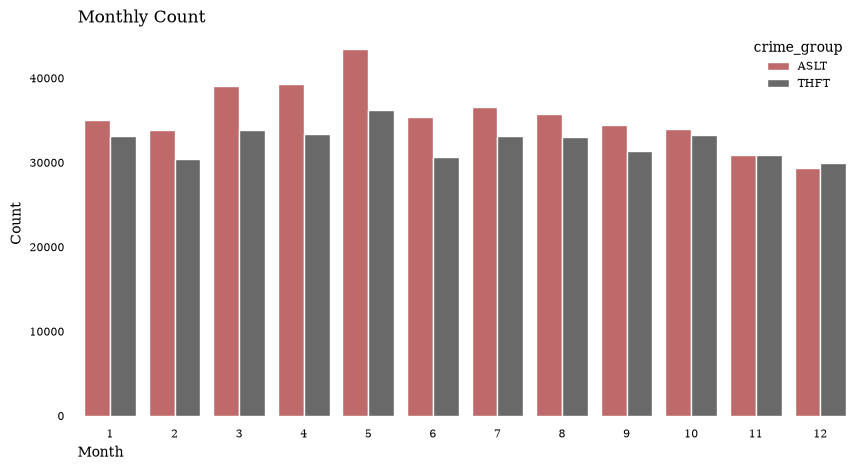

In [ ]:
df_crime['mdate'] = df_crime['ddate'].dt.month

grp = df_crime[['mdate', 'crime_group', 'id']]\
    .groupby(['mdate', 'crime_group'])\
    .count()\
    .reset_index()


sns.barplot(
    data=grp,
    x='mdate',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.title('Monthly Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Month', loc='left')
plt.box(False);

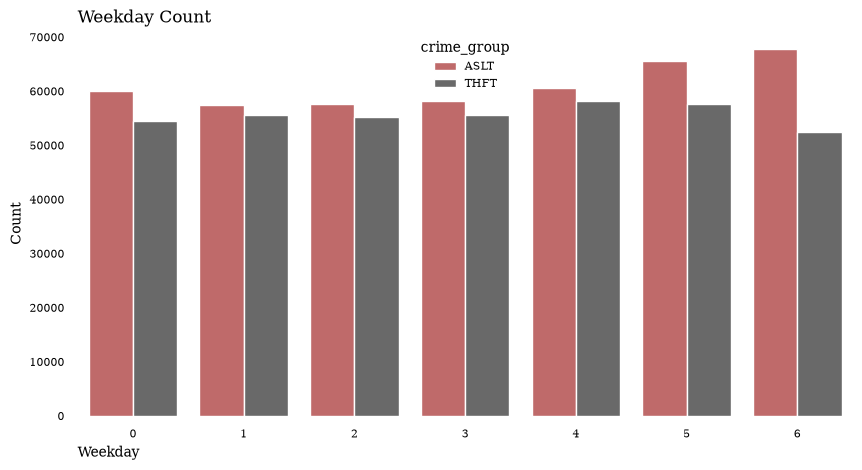

In [67]:
df_crime['weekday'] = df_crime['ddate'].dt.weekday

grp = df_crime[['weekday', 'crime_group', 'id']]\
    .groupby(['weekday', 'crime_group'])\
    .count()\
    .reset_index()


sns.barplot(
    data=grp,
    x='weekday',
    y='id',
    hue='crime_group',
    palette=colors
)

plt.title('Weekday Count', loc='left')
plt.ylabel('Count')
plt.xlabel('Weekday', loc='left')
plt.box(False);

### Aggregation per District

In [70]:
df_crime.head()

,id,arrest,domestic,district,community_area,crime_group,crime_distance,min_dist_station,max_dist_station,avg_cm_area,...,pct_housing_crowded,pct_hh_below_pvty,pct_16_unemployed,pct_25_without_hsd,pct_dependents,per_capita_income,hardship_index,ddate,month,weekday
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:03:00,12581802,0,0,10,29,ASLT,1.852004,1.852004,21.823778,129.112315,...,0.074,0.431,0.212,0.276,0.427,12034.0,87,2022-01-01,1,5
2022-01-01 00:04:00,12582232,0,0,12,28,ASLT,2.659790,2.659790,22.031854,78.080901,...,0.038,0.206,0.107,0.096,0.222,44689.0,15,2022-01-01,1,5
2022-01-01 00:05:00,12582704,0,0,9,61,ASLT,3.327426,3.327426,20.750551,74.037276,...,0.119,0.290,0.230,0.415,0.389,12765.0,91,2022-01-01,1,5
2022-01-01 00:05:00,12581815,0,0,11,26,ASLT,2.124182,2.124182,23.549729,109.321992,...,0.094,0.417,0.258,0.245,0.436,10934.0,92,2022-01-01,1,5
2022-01-01 00:05:00,12582341,0,0,4,48,ASLT,3.104587,3.104587,30.775613,95.610774,...,0.021,0.115,0.200,0.110,0.440,28887.0,38,2022-01-01,1,5


In [82]:
grp_daily = df_crime[['ddate', 'district', 'crime_group', 'id']]\
    .groupby(['ddate', 'district', 'crime_group'])\
    .count()\
    .reset_index()

grp_dst = grp_daily\
    .groupby(['district', 'crime_group'])\
    .agg(
        mean=('id', 'mean'),
        std=('id', 'std')
    )\
    .reset_index()

grp_dst['cv'] = grp_dst['std'] / grp_dst['mean']
grp_dst.sort_values('mean', ascending=False).head(10)

,district,crime_group,mean,std,cv
4,11,ASLT,19.758685,5.340843,0.270304
17,18,THFT,18.405087,6.024185,0.327311
7,12,THFT,18.029156,5.808534,0.322174
1,1,THFT,18.019863,7.240902,0.401829
36,6,ASLT,17.848635,5.076881,0.284441
19,19,THFT,17.841713,6.210822,0.348107
40,8,ASLT,17.069479,5.016683,0.293898
32,4,ASLT,16.374069,4.846075,0.295960
30,3,ASLT,15.639578,4.555717,0.291294
41,8,THFT,14.715881,4.893266,0.332516


In [85]:
grp_ma[['THFT_30d', 'ASLT_30d']].corr()

,THFT_30d,ASLT_30d
THFT_30d,1.000000,0.720155
ASLT_30d,0.720155,1.000000


### Decomposition

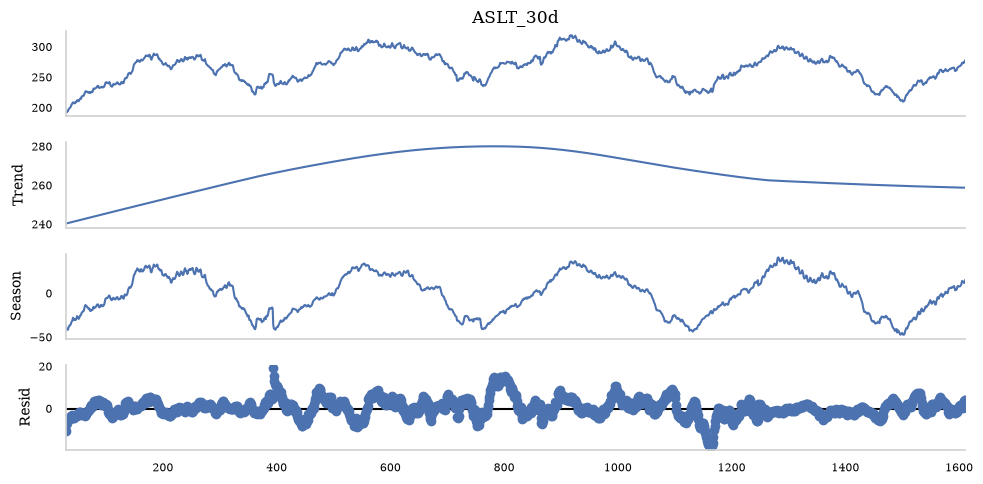

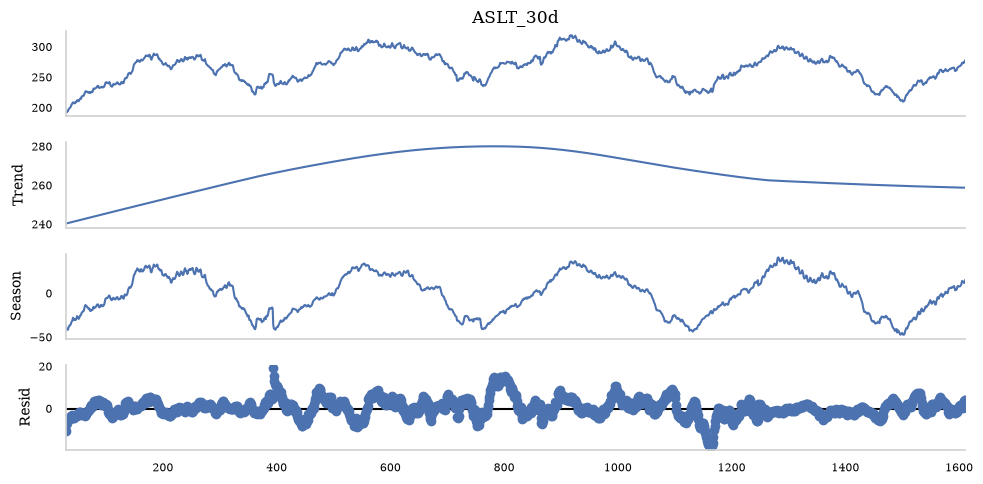

In [89]:
stl = STL(grp_ma['ASLT_30d'].dropna(), period=365)
res = stl.fit()
res.plot()

## Spatial Analysis

In [24]:
grp_dist = df_crime.query('crime_group == "ASLT"')[[
    'district', 'id', 'arrest',
    'domestic', 'hardship_index'
]].groupby('district')\
    .agg(
        count=('id', 'count'),
        arrest_rate=('arrest', 'mean'),
        domestic_rate=('domestic', 'mean'),
        avg_hardship=('hardship_index', 'mean')
    )
grp_dist

,count,arrest_rate,domestic_rate,avg_hardship
district,,,,
1,16987,0.276741,0.132513,9.115500
10,20489,0.297135,0.318171,89.543316
11,28913,0.377650,0.284232,83.912565
12,19786,0.159001,0.215102,29.833974
14,9885,0.187658,0.236419,27.261305
15,16641,0.251427,0.390001,73.000000
16,11638,0.219883,0.295841,27.416738
17,9956,0.178385,0.300221,41.331659
18,14102,0.249539,0.146575,1.133953


In [66]:
df_districts = pd.read_csv(f'{slv_path}/df_districts.csv')
df_districts['district'] = df_districts['district'].astype(int).astype(str)

# converting the geometry column to shapely objects
# by first replacing single quotes with double quotes in order to
# avoid json parsing errors 
df_districts['the_geom'] = df_districts['the_geom']\
    .str.replace("'", '"')\
    .apply(loads)

gdf_districts = df_districts.copy()
gdf_districts['geometry'] = gdf_districts['the_geom'].apply(shape)
gdf_districts = gpd.GeoDataFrame(
    gdf_districts,
    geometry='geometry',
    crs='EPSG:4326'
)

gdf_districts = gdf_districts.merge(
    grp_dist,
    how='left',
    on='district'
)

gdf_districts = gdf_districts.dropna(subset='count')
gdf_districts.head()

,the_geom,district,geometry,count,arrest_rate,domestic_rate,avg_hardship
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,"MULTIPOLYGON (((-87.71067 41.99737, -87.71067 ...",9956.0,0.178385,0.300221,41.331659
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20,"MULTIPOLYGON (((-87.66029 41.99092, -87.66029 ...",6937.0,0.192158,0.221710,20.994666
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19,"MULTIPOLYGON (((-87.64492 41.96973, -87.64431 ...",13888.0,0.163018,0.164891,9.687860
5,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",25,"MULTIPOLYGON (((-87.7174 41.93922, -87.71739 4...",19379.0,0.214562,0.341710,67.914908
6,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",14,"MULTIPOLYGON (((-87.69257 41.93943, -87.69253 ...",9885.0,0.187658,0.236419,27.261305


(np.float64(-87.96091293236427),
 np.float64(-87.50333825585992),
 np.float64(41.62563111851847),
 np.float64(42.04195494665791))

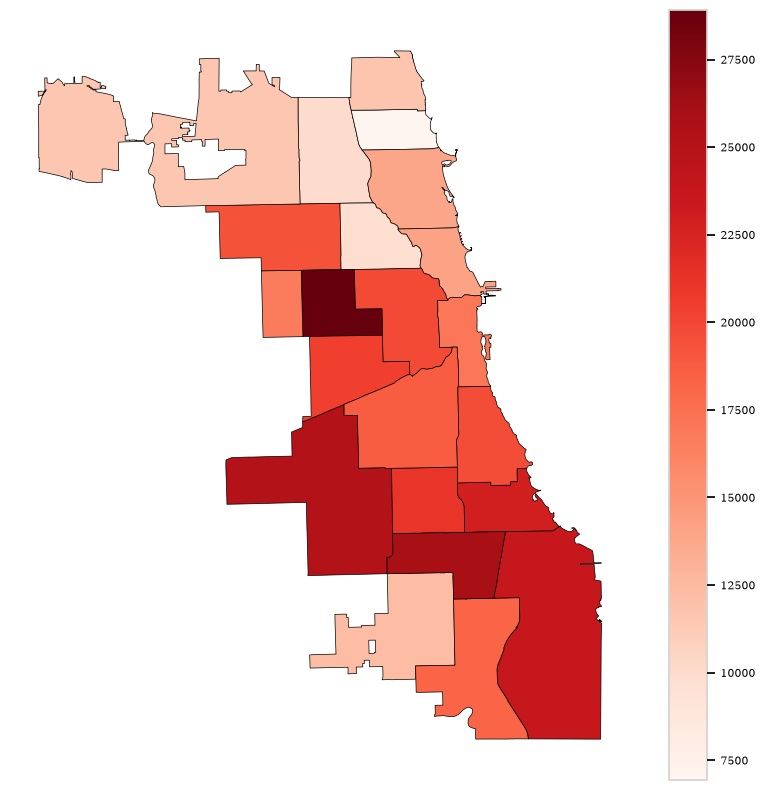

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_districts.plot(
    column='count',
    cmap='Reds',
    linewidth=.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.axis('off');

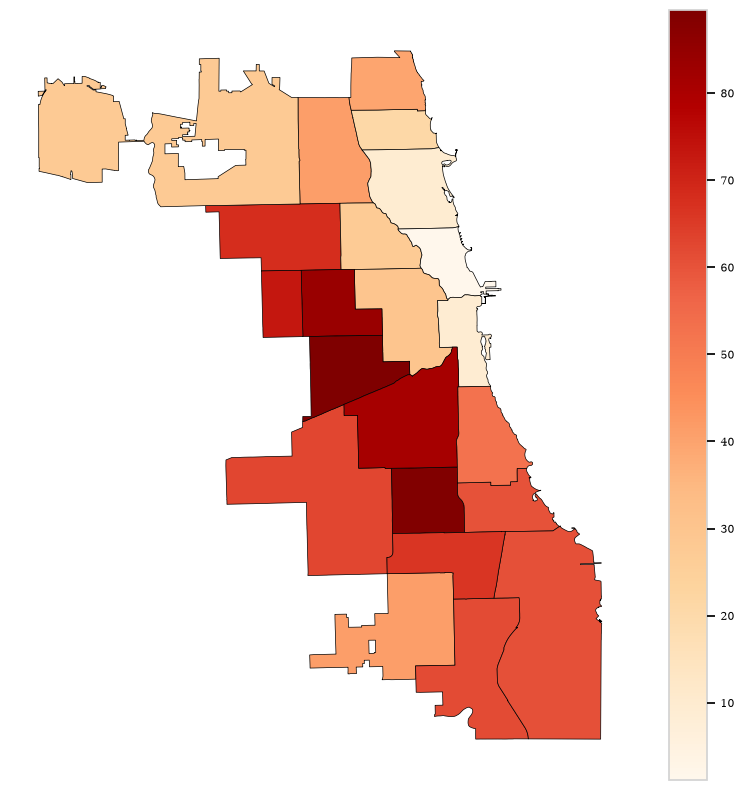

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_districts.plot(
    column='avg_hardship',
    cmap='OrRd',
    linewidth=.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.axis('off');

In [63]:
gdf_crimes = gpd.GeoDataFrame(
    df_crime,
    geometry=gpd.points_from_xy(
        df_crime['crime_lat'],
        df_crime['crime_lon']
    ),
    crs='EPSG:4326'
)

gdf_districts_ = gdf_districts.to_crs(3857)
gdf_crimes_ = gdf_crimes.to_crs(3857)

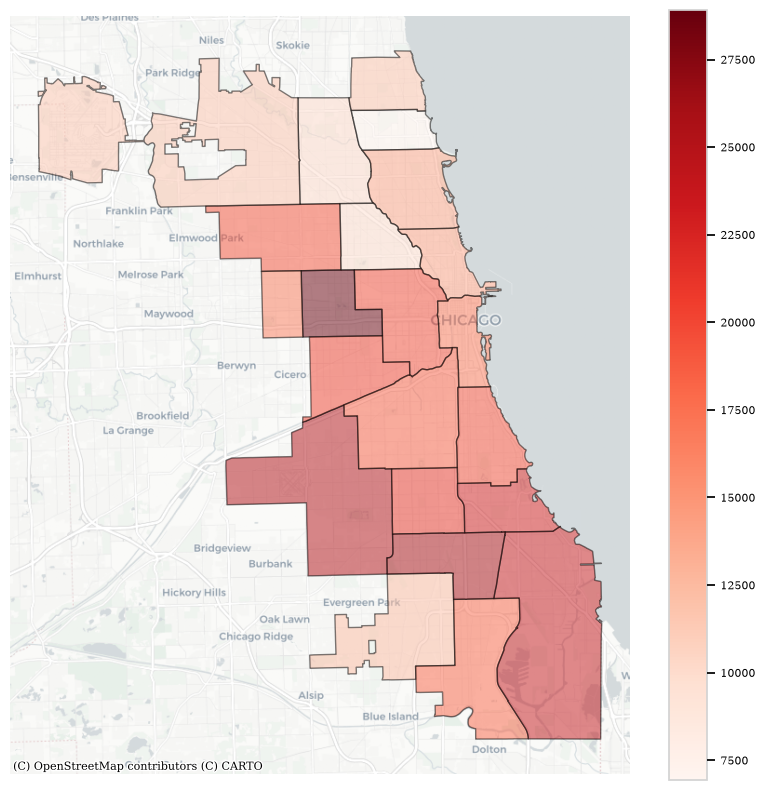

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_districts_.plot(
    column='count',
    cmap='Reds',
    alpha=.5,
    edgecolor='black',
    legend=True,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.axis('off');

### Spatial Autocorrelation

In [47]:
from libpysal.weights import Queen
from esda import Moran, Moran_Local

In [58]:
w = Queen.from_dataframe(gdf_districts)
w.transform = 'R'

mi = Moran(
    gdf_districts['count'],
    w
)

print(mi.I)
print(mi.p_sim)

0.43067906146348134
0.004


/var/folders/8q/r6p05j6x1nb253nlqpbjn42m0000gn/T/ipykernel_1005/1892231715.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_districts)


In [61]:
from splot.esda import moran_scatterplot

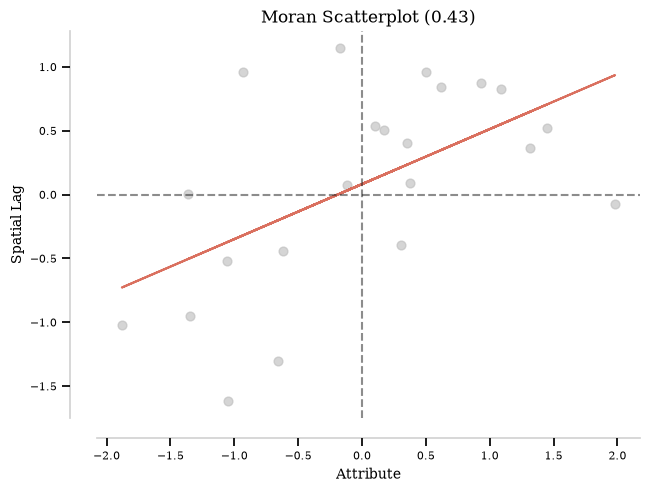

In [62]:
fig, ax = moran_scatterplot(mi)
plt.show()

In [67]:
lisa = Moran_Local(
    gdf_districts['count'],
    w
)

gdf_districts['lisa_cluster'] = lisa.q
gdf_districts['pvalue'] = lisa.p_sim
gdf_districts['sig'] = gdf_districts['pvalue'] < .05

gdf_districts

,the_geom,district,geometry,count,arrest_rate,domestic_rate,avg_hardship,lisa_cluster,pvalue,sig
0,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",17,"MULTIPOLYGON (((-87.71067 41.99737, -87.71067 ...",9956.0,0.178385,0.300221,41.331659,3,0.002,True
1,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",20,"MULTIPOLYGON (((-87.66029 41.99092, -87.66029 ...",6937.0,0.192158,0.221710,20.994666,3,0.007,True
4,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",19,"MULTIPOLYGON (((-87.64492 41.96973, -87.64431 ...",13888.0,0.163018,0.164891,9.687860,3,0.004,True
5,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",25,"MULTIPOLYGON (((-87.7174 41.93922, -87.71739 4...",19379.0,0.214562,0.341710,67.914908,4,0.182,False
6,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",14,"MULTIPOLYGON (((-87.69257 41.93943, -87.69253 ...",9885.0,0.187658,0.236419,27.261305,2,0.447,False
8,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",22,"MULTIPOLYGON (((-87.63632 41.73618, -87.63592 ...",12318.0,0.190372,0.350382,41.255561,2,0.057,False
9,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5,"MULTIPOLYGON (((-87.58776 41.72231, -87.58762 ...",18232.0,0.212593,0.385860,61.794482,1,0.195,False
10,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",24,"MULTIPOLYGON (((-87.67424 42.023, -87.66541 42...",11673.0,0.193010,0.289300,39.496702,3,0.016,True
11,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",16,"MULTIPOLYGON (((-87.80655 42.01896, -87.80655 ...",11638.0,0.219883,0.295841,27.416738,3,0.212,False
12,"{'type': 'MultiPolygon', 'coordinates': [[[[-8...",8,"MULTIPOLYGON (((-87.71442 41.82861, -87.71433 ...",25121.0,0.191155,0.328649,62.863819,1,0.143,False


In [68]:
from splot.esda import lisa_cluster

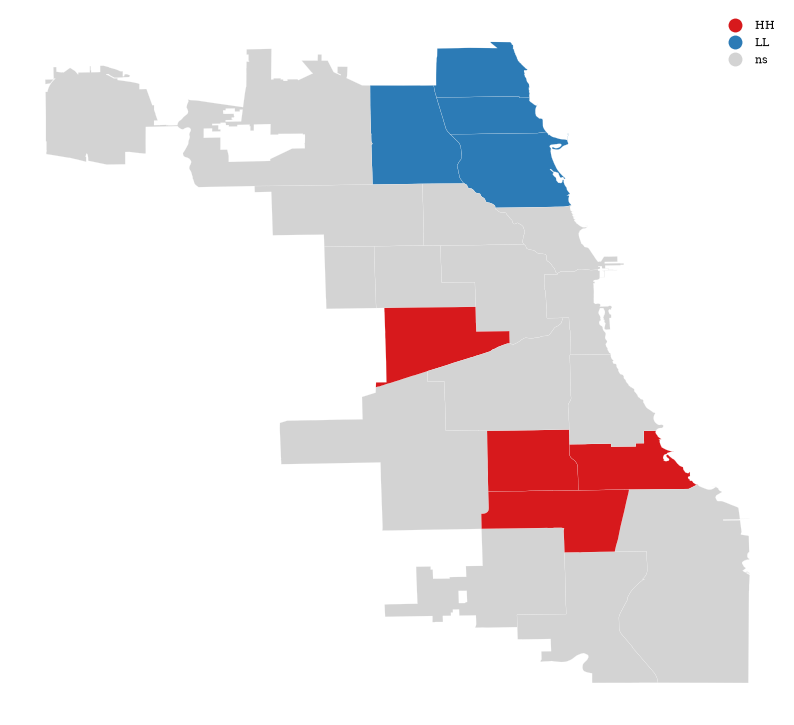

In [69]:
fig, ax = plt.subplots(figsize=(10, 10))

lisa_cluster(
    lisa,
    gdf_districts,
    p=.05,
    ax=ax
)

plt.show()